<h1 style="font-family:Georgia,serif;color:#1a252f;font-size:2em;border-bottom:3px solid #2980b9;padding-bottom:10px;margin-bottom:6px;">
  Notebook 02 &mdash; Reconhecimento de Entidades Nomeadas (NER)
</h1>
<p style="font-family:Georgia,serif;color:#666;font-size:1.05em;margin-top:4px;margin-bottom:22px;">
  Dissertações de Mestrado em Engenharia Elétrica e de Computação &mdash; Pipeline GLiNER com taxonomia de domínio
</p>
<div style="background:#f4f8fb;border-left:4px solid #2980b9;padding:12px 16px;border-radius:3px;font-family:sans-serif;font-size:0.92em;color:#333;line-height:1.65;">
  <strong>Objetivo:</strong> extrair entidades nomeadas dos textos produzidos pelo Notebook 01
  usando <strong>GLiNER</strong> com labels descritivos em português. A abordagem zero-shot elimina
  a necessidade de fine-tuning e permite definir tipos semânticos específicos ao domínio de
  Engenharia de Computação. Os artefatos gerados (<code>data/entities/gliner/</code>)
  alimentam diretamente o Notebook 03.
</div>
<br>
<table style="font-family:sans-serif;font-size:0.88em;color:#444;border-collapse:collapse;">
  <tr><td style="padding:3px 20px 3px 0;color:#888;">Modelo</td><td><code>urchade/gliner_multi-v2.1</code></td></tr>
  <tr><td style="padding:3px 20px 3px 0;color:#888;">Abordagem</td><td>Zero-shot &middot; multilíngue &middot; labels em linguagem natural</td></tr>
  <tr><td style="padding:3px 20px 3px 0;color:#888;">Dependência</td><td><code>pip install gliner</code></td></tr>
</table>

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">1. Configuração</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Importações, caminhos, estilo global e definição dos labels GLiNER.
  Os diretórios de saída são criados automaticamente.
</p>

In [1]:
import re
import json
import time
import warnings
from pathlib import Path
from collections import Counter
from itertools import combinations
from IPython.display import display, HTML

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

warnings.filterwarnings("ignore")

In [2]:
# ── Caminhos ─────────────────────────────────────────────────────────────────
ROOT         = Path("..")
DIR_TEXT     = ROOT / "data" / "extracted_text"
DIR_ENT      = ROOT / "data" / "entities" / "gliner"
DIR_FIGURES  = ROOT / "figures" / "02_ner_analysis"
DIR_RESULTS  = ROOT / "results" / "02_ner_analysis"
DIR_RESULTS_NB01 = ROOT / "results" / "01_corpus_exploration"
DIR_META     = ROOT / "metadados_teses"

for d in [DIR_ENT, DIR_FIGURES, DIR_RESULTS]:
    d.mkdir(parents=True, exist_ok=True)

JSON_FILES = sorted(DIR_TEXT.glob("*.json"))
TESE_IDS   = [f.stem for f in JSON_FILES]

print(f"Textos disponíveis ({len(TESE_IDS)}): {TESE_IDS}")
print()
for label, d in [("data/extracted_text", DIR_TEXT),
                  ("data/entities/gliner", DIR_ENT),
                  ("figures/02_ner_analysis", DIR_FIGURES),
                  ("results/02_ner_analysis", DIR_RESULTS)]:
    print(f"  {label:22s}  {'ok' if d.exists() else 'NAO ENCONTRADO'}")

Textos disponíveis (13): ['01', '03', '05', '09', '11', '12', '13', '14', '15', '16', '17', '18', '19']

  data/extracted_text     ok
  data/entities/gliner    ok
  figures/02_ner_analysis  ok
  results/02_ner_analysis  ok


In [3]:
# ── Estilo global ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9", "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.color": "#e2e2e2", "grid.linestyle": "--",
    "grid.linewidth": 0.6, "font.size": 11,
    "axes.titlesize": 12, "axes.labelsize": 11,
})

# ── Labels GLiNER e seus apelidos ──────────────────────────────────────
LABELS = [
    "linguagem de programação",
    "framework ou biblioteca de software",
    "hardware ou plataforma embarcada",
    "algoritmo ou técnica de inteligência artificial",
    "protocolo ou padrão de comunicação",
    "instituição de ensino ou pesquisa",
    "organização ou empresa de tecnologia",
    "pesquisador ou autor",
    "método ou técnica computacional",
]

LABEL_SHORT = {
    "linguagem de programação":                       "LANG",
    "framework ou biblioteca de software":             "FRAMEWORK",
    "hardware ou plataforma embarcada":                "HARDWARE",
    "algoritmo ou técnica de inteligência artificial": "ALGORITMO",
    "protocolo ou padrão de comunicação":              "PROTOCOLO",
    "instituição de ensino ou pesquisa":               "INSTITUICAO",
    "organização ou empresa de tecnologia":            "EMPRESA",
    "pesquisador ou autor":                            "AUTOR",
    "método ou técnica computacional":                 "METODO",
}

LABEL_COLORS = {
    "LANG":        "#85c1e9",
    "FRAMEWORK":   "#82e0aa",
    "HARDWARE":    "#f0b27a",
    "ALGORITMO":   "#bb8fce",
    "PROTOCOLO":   "#f7dc6f",
    "INSTITUICAO": "#aed6f1",
    "EMPRESA":     "#a9dfbf",
    "AUTOR":       "#f9e79f",
    "METODO":      "#fadbd8",
}

SHORT_LABELS = list(LABEL_SHORT.values())
print(f"Labels definidos ({len(LABELS)}):")
for full, short in LABEL_SHORT.items():
    print(f"  [{short:12s}]  {full}")

Labels definidos (9):
  [LANG        ]  linguagem de programação
  [FRAMEWORK   ]  framework ou biblioteca de software
  [HARDWARE    ]  hardware ou plataforma embarcada
  [ALGORITMO   ]  algoritmo ou técnica de inteligência artificial
  [PROTOCOLO   ]  protocolo ou padrão de comunicação
  [INSTITUICAO ]  instituição de ensino ou pesquisa
  [EMPRESA     ]  organização ou empresa de tecnologia
  [AUTOR       ]  pesquisador ou autor
  [METODO      ]  método ou técnica computacional


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">2. Carregamento dos Textos e Metadados</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Carrega o resumo do corpus gerado pelo Notebook 01 (<code>results/01_corpus_exploration/corpus_summary.csv</code>)
  e os textos extraídos em <code>data/extracted_text/</code>.
  Se o CSV de metadados não existir, o DataFrame é construído diretamente dos arquivos JSON.
</p>

In [4]:
corpus_csv = DIR_RESULTS_NB01 / "corpus_summary.csv"

if corpus_csv.exists():
    meta = pd.read_csv(corpus_csv, encoding="utf-8-sig")
    meta["tese_id"] = meta["tese_id"].astype(str).str.replace(".0", "", regex=False).str.zfill(2)
    # Mantém só os que têm JSON extraído
    meta = meta[meta["tese_id"].isin(TESE_IDS)].reset_index(drop=True)
    print(f"Metadados carregados de corpus_summary.csv: {len(meta)} documentos")
else:
    # Fallback: cria DataFrame mínimo a partir dos arquivos JSON
    meta = pd.DataFrame({"tese_id": TESE_IDS})
    print(f"corpus_summary.csv não encontrado. Usando {len(meta)} IDs dos JSONs.")
    print("Execute o Notebook 01 para enriquecer os metadados.")

# Coluna de label para eixos dos gráficos
if "autor" in meta.columns and "ano" in meta.columns:
    meta["sobrenome"] = meta["autor"].apply(lambda x: str(x).split()[-1].title())
    meta["label_eixo"] = meta.apply(lambda r: f"{r['sobrenome']} ({r['ano']})", axis=1)
else:
    meta["label_eixo"] = meta["tese_id"]

print()
meta[[c for c in ["tese_id", "autor", "ano", "titulo"] if c in meta.columns]].assign(
    titulo=meta["titulo"].str[:65] + "..." if "titulo" in meta.columns else ""
)

Metadados carregados de corpus_summary.csv: 13 documentos



,tese_id,autor,ano,titulo
0,19,Tiago Fernando Barbosa de Sousa,2014,Equalização Neural Aplicada a Sistemas com Mod...
1,18,Átila Varela Ferreira Medeiros de Oliveira,2015,Estratégia de navegação com planejamento dinâm...
2,14,Sérgio Natan Silva,2016,Simulador de Tempo Real para Sistemas Dinâmico...
3,15,Caroline Albuquerque Dantas Silva,2016,Proposta de equalizador cego baseado em algori...
4,16,Lucileide Medeiros Dantas da Silva,2016,Proposta de arquitetura em Hardware para FPGA ...
5,17,Carlos Eduardo de Barros Santos Júnior,2016,Proposta de Implementação dos Algoritmos MD5 e...
6,12,Matheus Fernandes Torquato,2017,Proposta de implementação paralela de algoritm...
7,13,Daniel Holanda Noronha,2017,Proposta de Implementação em FPGA de Máquina d...
8,11,MARIA GRACIELLY FERNANDES COUTINHO,2018,Reconfigurable Computing applied to the Deep L...
9,09,EMANOEL LUCAS RODRIGUES COSTA,2020,Aprendizagem de máquina aplicada ao agrupament...


In [5]:
def load_json(tese_id: str) -> dict:
    with open(DIR_TEXT / f"{tese_id}.json", encoding="utf-8") as fh:
        return json.load(fh)

CORPUS = {tid: load_json(tid) for tid in TESE_IDS}

print(f"Corpus carregado: {len(CORPUS)} documentos")
print(f"  Total de páginas  : {sum(len(d['pages']) for d in CORPUS.values()):,}")
print(f"  Total de linhas   : {sum(len(d['lines']) for d in CORPUS.values()):,}")

Corpus carregado: 13 documentos
  Total de páginas  : 1,000
  Total de linhas   : 17,540


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">3. Pré-processamento dos Textos</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Antes do NER, cada documento passa por três etapas de limpeza:
</p>
<ol style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.8;max-width:780px;">
  <li><strong>Remoção da seção de referências</strong> &mdash; detecta a página inicial de referências
      e descarta tudo a partir dela. Elimina autores citados que geram ruído no tipo <em>AUTOR</em>.</li>
  <li><strong>Filtragem de linhas estruturais</strong> &mdash; remove linhas com padrão de
      sumário (<code>. . . . .</code>), linhas numéricas e fragmentos curtos.</li>
  <li><strong>Agrupamento em chunks</strong> &mdash; agrupa <code>CHUNK_SIZE</code> linhas
      consecutivas em um bloco de texto para o GLiNER. Blocos maiores fornecem mais
      contexto sintático sem exceder o limite de tokens do modelo.</li>
</ol>

In [6]:
CHUNK_SIZE = 4   # linhas por chunk — ajuste entre 3 e 6 se necessário

REF_RE = re.compile(
    r'^\s*(referências\s*(bibliográficas)?|references?|bibliography)\s*$',
    re.IGNORECASE
)
DOTS_RE   = re.compile(r'\.\s*\.\s*\.')          # padrão de sumário
NUM_RE    = re.compile(r'^[\d\s\.\-,]+$')         # só números/pontuação


def preprocess(tese_data: dict) -> list[str]:
    """Remove seção de referências e produz chunks de texto para o GLiNER.

    Parâmetros
    ----------
    tese_data : dict — conteúdo do JSON de texto extraído (campos 'pages', 'lines').

    Retorna
    -------
    list[str] — chunks de texto prontos para inferência.
    """
    pages = tese_data["pages"]

    # ── 1. Corta na seção de referências ─────────────────────────────────────
    cut_at = len(pages)
    for i, page in enumerate(pages):
        first_line = page.strip().split("\n")[0].strip()
        if REF_RE.match(first_line):
            cut_at = i
            break

    # ── 2. Extrai e filtra linhas ─────────────────────────────────────────────
    clean_lines = []
    for page in pages[:cut_at]:
        for line in page.split("\n"):
            line = line.strip()
            if len(line) < 25:              continue  # muito curta
            if DOTS_RE.search(line):        continue  # padrão de sumário
            if NUM_RE.match(line):          continue  # só números
            # Filtra linhas dominadas por caracteres especiais
            alpha_ratio = sum(c.isalpha() for c in line) / len(line)
            if alpha_ratio < 0.4:           continue
            clean_lines.append(line)

    # ── 3. Agrupa em chunks ───────────────────────────────────────────────────
    chunks = []
    for i in range(0, len(clean_lines), CHUNK_SIZE):
        text = " ".join(clean_lines[i:i + CHUNK_SIZE])
        text = re.sub(r"(\w)-\s+(\w)", r"\1\2", text)   # corrige hifenização
        text = re.sub(r"\s{2,}", " ", text).strip()      # normaliza espaços
        if len(text) >= 60:
            chunks.append(text)

    return chunks


print("Função preprocess definida.")
print(f"CHUNK_SIZE = {CHUNK_SIZE} linhas por chunk")

Função preprocess definida.
CHUNK_SIZE = 4 linhas por chunk


In [7]:
# ── Aplica pré-processamento e exibe estatísticas ────────────────────────────
CHUNKS = {tid: preprocess(CORPUS[tid]) for tid in TESE_IDS}

print(f"{'ID':>4}  {'Label':24}  {'Páginas orig.':>13}  {'Linhas limpas (est.)':>20}  {'Chunks':>7}")
print("  " + "-" * 72)

for tid in TESE_IDS:
    n_pages  = len(CORPUS[tid]["pages"])
    n_chunks = len(CHUNKS[tid])
    row      = meta[meta["tese_id"] == tid]
    lbl      = row["label_eixo"].values[0] if len(row) else tid
    # Estima linhas limpas pelo chunk count
    n_lines_est = n_chunks * CHUNK_SIZE
    print(f"  {tid:>3}  {lbl:24}  {n_pages:>13}  {n_lines_est:>20}  {n_chunks:>7}")

total_chunks = sum(len(v) for v in CHUNKS.values())
print(f"\n  Total de chunks a processar: {total_chunks:,}")

  ID  Label                     Páginas orig.  Linhas limpas (est.)   Chunks
  ------------------------------------------------------------------------
   01  Goldbarg (2024)                      58                   852      213
   03  Souza (2022)                        131                  1460      365
   05  Azevedo (2022)                       96                  1456      364
   09  Costa (2020)                         90                  1560      390
   11  Coutinho (2018)                      63                  1044      261
   12  Torquato (2017)                      66                  1064      266
   13  Noronha (2017)                       66                  1064      266
   14  Silva (2016)                         75                  1004      251
   15  Silva (2016)                         81                  1196      299
   16  Silva (2016)                         65                   892      223
   17  Júnior (2016)                        66                  1104

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">4. Carregamento do Modelo GLiNER</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  <code>urchade/gliner_multi-v2.1</code> é um modelo de NER zero-shot treinado em múltiplos idiomas.
  Ele recebe um texto e uma lista de labels em linguagem natural, retornando os spans que
  correspondem a cada categoria. O parâmetro <code>threshold</code> controla a sensibilidade:
  valores mais baixos aumentam o recall (mais entidades, mais ruído); valores mais altos
  aumentam a precisão (menos entidades, mais confiáveis). A calibração é feita na próxima seção.
</p>

In [8]:
import os
import time

# ── Configurar progresso (compatível com versão 1.10.2) ──────────────────────
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "0"

try:
    from huggingface_hub.utils.logging import set_verbosity_info
    set_verbosity_info()
except (ImportError, AttributeError):
    # Versão 1.10.2 não tem esse módulo, só usar env var
    pass

from gliner import GLiNER

GLINER_MODEL_ID = "urchade/gliner_multi-v2.1"

print(f"Carregando {GLINER_MODEL_ID} ...")
t0 = time.time()
gliner_model = GLiNER.from_pretrained(GLINER_MODEL_ID)
print(f"Modelo carregado em {time.time() - t0:.1f}s")

Carregando urchade/gliner_multi-v2.1 ...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Modelo carregado em 14.7s


<h3 style="font-family:Georgia,serif;color:#34495e;margin-top:22px;">Calibração do threshold</h3>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Testa o modelo em três trechos representativos do corpus com três valores de threshold.
  Inspecione os resultados e ajuste <code>THRESHOLD</code> antes de rodar o corpus inteiro.
  Um threshold entre <strong>0.30 e 0.45</strong> costuma equilibrar bem precisão e cobertura
  em texto técnico misto PT/EN.
</p>

In [9]:
# Amostras representativas dos dois temas do corpus
CALIBRATION_TEXTS = [
    # Hardware / FPGA
    ("HW",  "A implementação do algoritmo genético em FPGA utilizando a ferramenta "
             "System Generator da Xilinx foi realizada em VHDL sobre a plataforma "
             "Virtex-6. O código foi sintetizado com o software ISE da Intel."),
    # ML / Deep Learning
    ("ML",  "Neste trabalho, uma CNN baseada na arquitetura ResNet foi treinada com "
             "TensorFlow e Python para classificar variantes do SARS-CoV-2. "
             "O dataset GISAID foi utilizado como fonte de sequências genômicas."),
    # IoT / Protocolos
    ("IoT", "O sistema embarcado no ESP32 coleta dados via protocolo MQTT e os "
             "transmite para um servidor Node.js. A comunicação segura usa TLS 1.3 "
             "e os dados são armazenados no banco de dados InfluxDB."),
]

for thr in [0.30, 0.40, 0.50]:
    print(f"\n{'='*60}")
    print(f"  threshold = {thr}")
    print(f"{'='*60}")
    for tag, text in CALIBRATION_TEXTS:
        ents = gliner_model.predict_entities(text, LABELS, threshold=thr, flat_ner=True)
        print(f"  [{tag}] {len(ents)} entidades:")
        for e in ents:
            short = LABEL_SHORT.get(e['label'], e['label'])
            print(f"    [{short:12s}] {e['text']:30s}  score={e['score']:.3f}")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



  threshold = 0.3
  [HW] 6 entidades:
    [HARDWARE    ] FPGA                            score=0.448
    [EMPRESA     ] Xilinx                          score=0.799
    [LANG        ] VHDL                            score=0.968
    [HARDWARE    ] Virtex-6                        score=0.445
    [FRAMEWORK   ] ISE                             score=0.464
    [EMPRESA     ] Intel                           score=0.527
  [ML] 3 entidades:
    [LANG        ] ResNet                          score=0.413
    [FRAMEWORK   ] TensorFlow                      score=0.718
    [LANG        ] Python                          score=0.944
  [IoT] 4 entidades:
    [HARDWARE    ] ESP32                           score=0.633
    [PROTOCOLO   ] MQTT                            score=0.953
    [HARDWARE    ] Node.js                         score=0.631
    [PROTOCOLO   ] TLS 1.3                         score=0.905

  threshold = 0.4
  [HW] 6 entidades:
    [HARDWARE    ] FPGA                            score=0.448

In [10]:
THRESHOLD = 0.35  

print(f"Threshold selecionado: {THRESHOLD}")

Threshold selecionado: 0.35


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">5. Execução do NER sobre o Corpus</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  O GLiNER é aplicado a cada chunk de texto. Os resultados são salvos por documento em
  <code>data/entities/gliner/&lt;id&gt;.json</code>. Re-execuções reutilizam o cache
  automaticamente — remova os JSONs para forçar reprocessamento.
</p>
<div style="background:#fff8f0;border-left:4px solid #e67e22;padding:10px 14px;border-radius:3px;font-family:sans-serif;font-size:0.88em;color:#444;line-height:1.6;margin-top:8px;">
  <strong>Tempo estimado (CPU):</strong> cerca de 1&ndash;3 minutos por documento, dependendo
  do número de chunks. O corpus completo leva tipicamente 20&ndash;40 minutos na primeira execução.
</div>

In [11]:
def run_gliner(tese_id: str, chunks: list[str],
               model, labels: list[str], threshold: float) -> list[dict]:
    """Executa GLiNER em todos os chunks de um documento.

    Parâmetros
    ----------
    tese_id   : identificador do documento.
    chunks    : lista de strings produzida por preprocess().
    model     : instância GLiNER já carregada.
    labels    : lista de labels descritivos.
    threshold : limiar de confiança (0–1).

    Retorna
    -------
    Lista de dicionários de entidade no formato padrão.
    """
    entities = []
    for idx, chunk in enumerate(chunks):
        if len(chunk.strip()) < 20:
            continue
        try:
            results = model.predict_entities(
                chunk, labels, threshold=threshold, flat_ner=True
            )
        except Exception:
            continue

        for r in results:
            text = r["text"].strip()
            if not text:
                continue
            entities.append({
                "text":       text,
                "text_norm":  text.lower().strip(),
                "label":      LABEL_SHORT.get(r["label"], r["label"]),
                "label_full": r["label"],
                "score":      round(float(r["score"]), 4),
                "chunk_idx":  idx,
                "tese_id":    tese_id,
            })

    return entities


print("Função run_gliner definida.")

Função run_gliner definida.


In [12]:
t_global = time.time()
print(f"Executando GLiNER (threshold={THRESHOLD}) em {len(TESE_IDS)} documentos...\n")
print(f"  {'ID':>3}  {'Label':24}  {'Chunks':>7}  {'Entidades':>10}  {'Tempo':>8}")
print("  " + "-" * 62)

stats = []

for tid in TESE_IDS:
    out_path  = DIR_ENT / f"{tid}.json"
    row       = meta[meta["tese_id"] == tid]
    lbl       = row["label_eixo"].values[0] if len(row) else tid
    n_chunks  = len(CHUNKS[tid])
    t1        = time.time()

    if out_path.exists():
        with open(out_path, encoding="utf-8") as fh:
            entities = json.load(fh)
        flag = "(cache)"
        elapsed = 0.0
    else:
        entities = run_gliner(tid, CHUNKS[tid], gliner_model, LABELS, THRESHOLD)
        with open(out_path, "w", encoding="utf-8") as fh:
            json.dump(entities, fh, ensure_ascii=False, indent=2)
        elapsed = time.time() - t1
        flag = ""

    n = len(entities)
    stats.append({"tese_id": tid, "n_chunks": n_chunks, "n_entidades": n})
    print(f"  {tid:>3}  {lbl:24}  {n_chunks:>7}  {n:>10}  {elapsed:>7.1f}s  {flag}")

print(f"\n  Total: {sum(s['n_entidades'] for s in stats):,} entidades")
print(f"  Tempo total: {time.time()-t_global:.1f}s")
print(f"  Arquivos salvos em: {DIR_ENT}")

Executando GLiNER (threshold=0.35) em 13 documentos...

   ID  Label                      Chunks   Entidades     Tempo
  --------------------------------------------------------------
   01  Goldbarg (2024)               213         331      0.0s  (cache)
   03  Souza (2022)                  365         540      0.0s  (cache)
   05  Azevedo (2022)                364         476      0.0s  (cache)
   09  Costa (2020)                  390         312      0.0s  (cache)
   11  Coutinho (2018)               261         586      0.0s  (cache)
   12  Torquato (2017)               266         585      0.0s  (cache)
   13  Noronha (2017)                266         585      0.0s  (cache)
   14  Silva (2016)                  251         608      0.0s  (cache)
   15  Silva (2016)                  299         615      0.0s  (cache)
   16  Silva (2016)                  223         504      0.0s  (cache)
   17  Júnior (2016)                 276         692      0.0s  (cache)
   18  Oliveira (2015)  

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">6. Normalização e Filtragem</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Após a extração, o notebook aplica normalização canônica, remoção de entidades
  genéricas, correção de conflitos de tipo, limiares mínimos de score por label
  e filtros de comprimento/frequência no corpus. O tipo <strong>AUTOR</strong> recebe
  um critério adicional para reduzir ruído bibliográfico.
</p>

In [13]:
# ── Carrega todos os JSONs em um DataFrame único ──────────────────────────────
rows = []
for f in sorted(DIR_ENT.glob("*.json")):
    with open(f, encoding="utf-8") as fh:
        for e in json.load(fh):
            rows.append(e)

df_raw = pd.DataFrame(rows)
print(f"Entidades brutas: {len(df_raw):,}  |  únicas: {df_raw['text_norm'].nunique():,}")
print()
print("Por tipo (bruto):")
print(df_raw["label"].value_counts().to_string())

Entidades brutas: 6,512  |  únicas: 2,236

Por tipo (bruto):
label
AUTOR          2402
HARDWARE       1177
ALGORITMO       955
METODO          954
LANG            272
PROTOCOLO       235
FRAMEWORK       182
INSTITUICAO     176
EMPRESA         159


In [14]:
# ── Mapa de normalização de plurais e variantes comuns 
# Casos específicos do corpus de dissertações/tese de mestrado.

NORM_MAP = {
    # Plurais de termos técnicos
    "algoritmos genéticos":    "algoritmo genético",
    "ag":                       "algoritmo genético",
    "redes neurais":           "rede neural",
    "redes neurais artificiais": "rede neural",
    "redes neurais convolucionais": "rede neural convolucional",
    "fpgas":                   "fpga",
    "field programmable gate array": "fpga",
    "field-programmable gate array": "fpga",
    "cnns":                    "cnn",
    "lstms":                   "lstm",
    "svms":                    "svm",
    "microcontroladores":      "microcontrolador",
    "microprocessadores":      "microprocessador",
    # Variantes de grafia
    "sars-cov2":               "sars-cov-2",
    "covid 19":                "covid-19",
    "deep learning":           "deep learning",
    "aprendizagem profunda":   "deep learning",
    "machine learning":        "machine learning",
    "internet das coisas":     "iot",
    "internet of things":      "iot",
    "universidade federal do rio grande do norte": "ufrn",
    "mestrado em engenharia elétrica e de computação": "meec",
    "mestrado em engenharia elétrica": "mee",
    "marcelo a. c. fernandes": "marcelo augusto costa fernandes",
    "marcelo augusto costa": "marcelo augusto costa fernandes",
    "prof. dr. marcelo augusto costa fernandes": "marcelo augusto costa fernandes",
    "prof dr marcelo augusto costa fernandes": "marcelo augusto costa fernandes",
}

ENTITY_BLOCKLIST = {
    "hardware", "algoritmo", "algoritmo 1", "algoritmo 2", "algoritmo 3",
    "autores", "método", "metodo", "sistema", "modelo", "figura",
    "tabela", "equação", "equacao", "capítulo", "capitulo",
    "chapter", "abstract", "keywords", "referências", "references"
}

AUTOR_BLOCKLIST = {
    "autor", "autores", "et al", "da silva", "de souza", "de oliveira",
    "dos santos", "li", "wang", "ding", "luo", "godard", "floyd",
    "haykin"
}

TYPE_OVERRIDE = {
    "cnn": "ALGORITMO",
    "lstm": "ALGORITMO",
    "svm": "ALGORITMO",
    "som": "ALGORITMO",
    "dft": "ALGORITMO",
    "ml": "METODO",
    "pca": "METODO",
}

SCORE_MIN_BY_LABEL = {
    "AUTOR": 0.75,
    "METODO": 0.45,
    "ALGORITMO": 0.40,
    "LANG": 0.40,
    "HARDWARE": 0.38,
    "FRAMEWORK": 0.38,
    "PROTOCOLO": 0.38,
    "EMPRESA": 0.38,
    "INSTITUICAO": 0.40,
}


def normalize_text(text: str) -> str:
    """Normaliza forma canônica da entidade."""
    t = text.strip().lower()
    t = re.sub(r"\s{2,}", " ", t)
    return NORM_MAP.get(t, t)


def is_valid_autor(text: str) -> bool:
    """Aceita apenas nomes com >= 2 tokens válidos e reduz ruído bibliográfico."""
    tokens = text.strip().split()
    capitalized = [t for t in tokens if t and t[0].isupper() and len(t) > 1]
    text_norm = normalize_text(text)
    return len(capitalized) >= 2 and text_norm not in AUTOR_BLOCKLIST


print("Funções de normalização definidas.")

Funções de normalização definidas.


In [15]:
FREQ_MIN = 3    # mínimo de ocorrências no corpus inteiro
LEN_MIN  = 3    # mínimo de caracteres

# Aplica normalização
df = df_raw.copy()
df["text_norm"] = df["text"].apply(normalize_text)

# Corrige conflitos de tipo para siglas/técnicas conhecidas
df["label"] = df.apply(lambda r: TYPE_OVERRIDE.get(r["text_norm"], r["label"]), axis=1)

# Filtro de ruído geral
df = df[~df["text_norm"].isin(ENTITY_BLOCKLIST)].copy()

# Filtro de AUTOR: exige nome completo e score mínimo mais alto
mask_autor = (df["label"] == "AUTOR") & ~df["text"].apply(is_valid_autor)
df = df[~mask_autor].copy()

# Limiar mínimo de score por label
df = df[df.apply(lambda r: r["score"] >= SCORE_MIN_BY_LABEL.get(r["label"], THRESHOLD), axis=1)].copy()

# Filtro de comprimento mínimo
df = df[df["text_norm"].str.len() >= LEN_MIN].copy()

# Filtro de frequência mínima
freq = df["text_norm"].value_counts()
df   = df[df["text_norm"].map(freq) >= FREQ_MIN].copy()

# Remove pontuação/números puros que sobreviveram
df = df[df["text_norm"].str.contains(r'[a-záéíóúâêîôûãõàç]', case=False, na=False)].copy()

df = df.reset_index(drop=True)

print(f"Após normalização e filtros:")
print(f"  Ocorrências : {len(df_raw):>7,}  →  {len(df):>7,}")
print(f"  Únicas      : {df_raw['text_norm'].nunique():>7,}  →  {df['text_norm'].nunique():>7,}")
print()
print("Por tipo (filtrado):")
print(df["label"].value_counts().to_string())

Após normalização e filtros:
  Ocorrências :   6,512  →    2,458
  Únicas      :   2,236  →      197

Por tipo (filtrado):
label
HARDWARE       706
ALGORITMO      627
METODO         340
AUTOR          169
LANG           157
INSTITUICAO    128
FRAMEWORK      116
PROTOCOLO      112
EMPRESA        103


In [16]:
# ── Distribuição de frequências: mostra onde o corte FREQ_MIN está ────────────
freq_dist = df_raw["text_norm"].value_counts()
thresholds = [1, 2, 3, 5, 10, 20]

print("Únicas por limiar de frequência mínima:")
print(f"  {'freq >=':>8}  {'únicas':>8}  {'ocorrências':>13}")
print("  " + "-" * 34)
for thr in thresholds:
    u = (freq_dist >= thr).sum()
    o = freq_dist[freq_dist >= thr].sum()
    marker = "  <-- selecionado" if thr == FREQ_MIN else ""
    print(f"  {thr:>8}  {u:>8,}  {o:>13,}{marker}")

Únicas por limiar de frequência mínima:
   freq >=    únicas    ocorrências
  ----------------------------------
         1     2,236          6,512
         2       936          5,212
         3       465          4,270  <-- selecionado
         5       202          3,372
        10        83          2,595
        20        34          1,942


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">7. Distribuição por Tipo de Entidade</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Proporção e contagem de ocorrências por tipo após os filtros.
  A distribuição revela o perfil temático do corpus: corpora de hardware tendem a
  dominar HARDWARE e ALGORITMO; corpora de sistemas tendem a ter mais PROTOCOLO e FRAMEWORK.
</p>

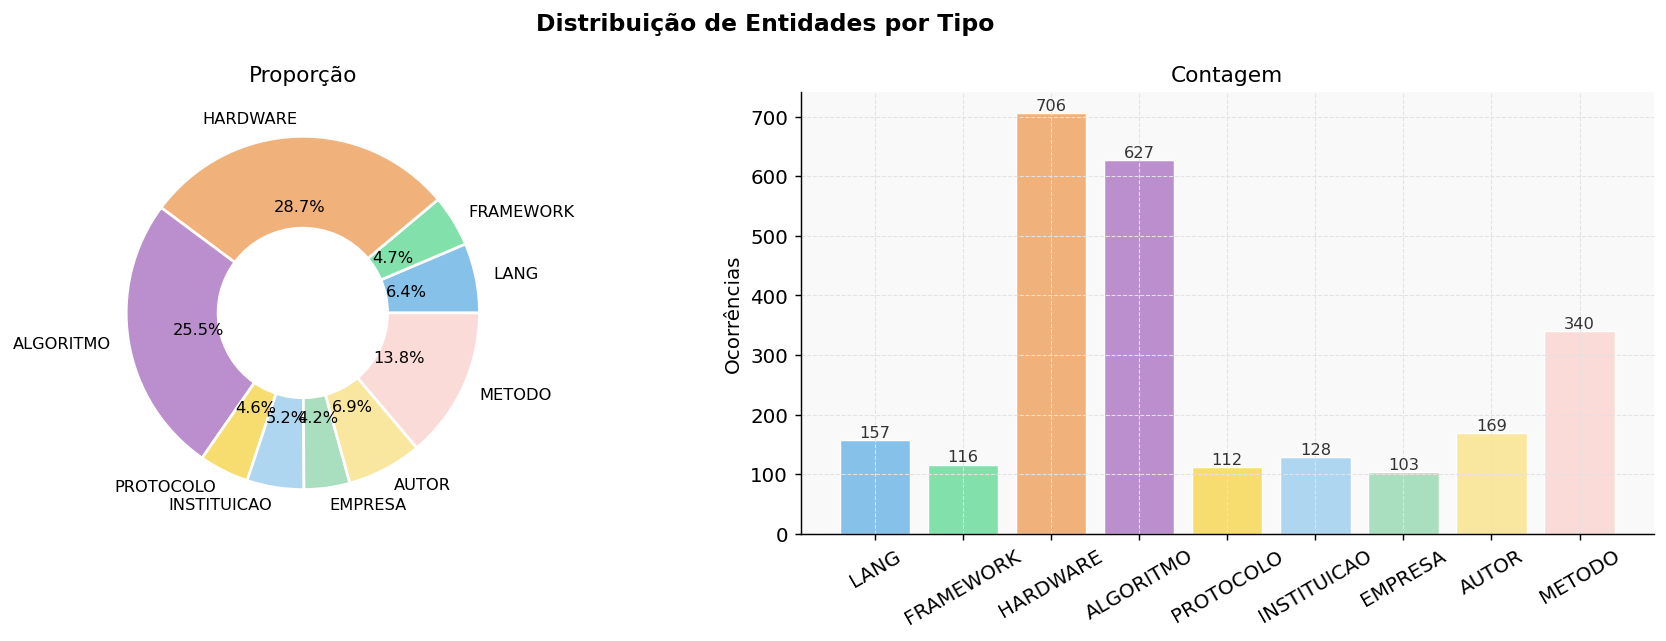

Figura salva: ../figures/02_ner_analysis/06_distribuicao_tipos.png


In [17]:
label_counts = df["label"].value_counts().reindex(
    [l for l in SHORT_LABELS if l in df["label"].values], fill_value=0
)
cores = [LABEL_COLORS.get(l, "#aaaaaa") for l in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribuição de Entidades por Tipo", fontsize=13, fontweight="bold")

# Rosca
axes[0].pie(label_counts.values, labels=label_counts.index,
            autopct="%1.1f%%", colors=cores,
            wedgeprops=dict(width=0.52, edgecolor="white", linewidth=1.5),
            textprops={"fontsize": 9})
axes[0].set_title("Proporção")

# Barras
bars = axes[1].bar(label_counts.index, label_counts.values,
                   color=cores, edgecolor="white", linewidth=0.8)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 5,
                 f"{h:,}", ha="center", fontsize=9, color="#333")
axes[1].set_title("Contagem")
axes[1].set_ylabel("Ocorrências")
axes[1].tick_params(axis="x", rotation=30)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
fig_path = DIR_FIGURES / "06_distribuicao_tipos.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">8. Entidades Mais Frequentes</h2>

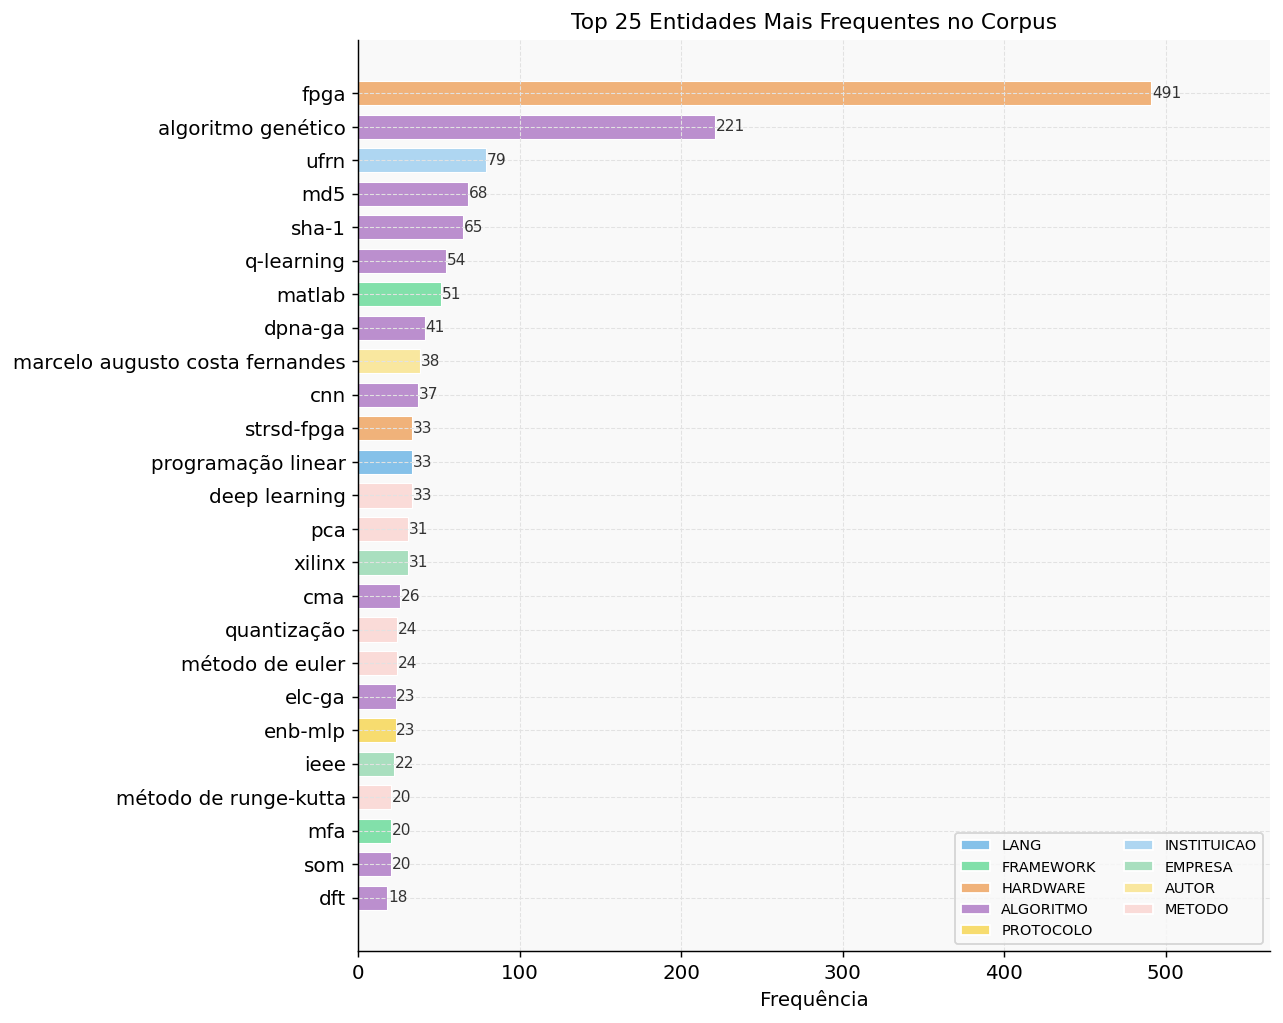

Figura salva: ../figures/02_ner_analysis/07_top25_entidades.png


In [18]:
# ── Top-25 geral ──────────────────────────────────────────────────────────────
top25 = df["text_norm"].value_counts().head(25)

# Cor de cada barra pelo tipo da entidade mais frequente
def cor_por_entidade(text_norm):
    lbl = df[df["text_norm"] == text_norm]["label"].mode()
    return LABEL_COLORS.get(lbl.iloc[0], "#aaaaaa") if len(lbl) else "#aaaaaa"

cores25 = [cor_por_entidade(t) for t in top25.index]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top25.index[::-1], top25.values[::-1],
               color=cores25[::-1], edgecolor="white", linewidth=0.6, height=0.72)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f"{w:,.0f}", va="center", fontsize=8.5, color="#333")
ax.set_title("Top 25 Entidades Mais Frequentes no Corpus")
ax.set_xlabel("Frequência")
ax.set_xlim(0, top25.max() * 1.15)

# Legenda de tipos
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=LABEL_COLORS[l], edgecolor="white", label=l)
                   for l in SHORT_LABELS if l in LABEL_COLORS]
ax.legend(handles=legend_elements, fontsize=8, frameon=True,
          loc="lower right", ncol=2)

plt.tight_layout()
fig_path = DIR_FIGURES / "07_top25_entidades.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

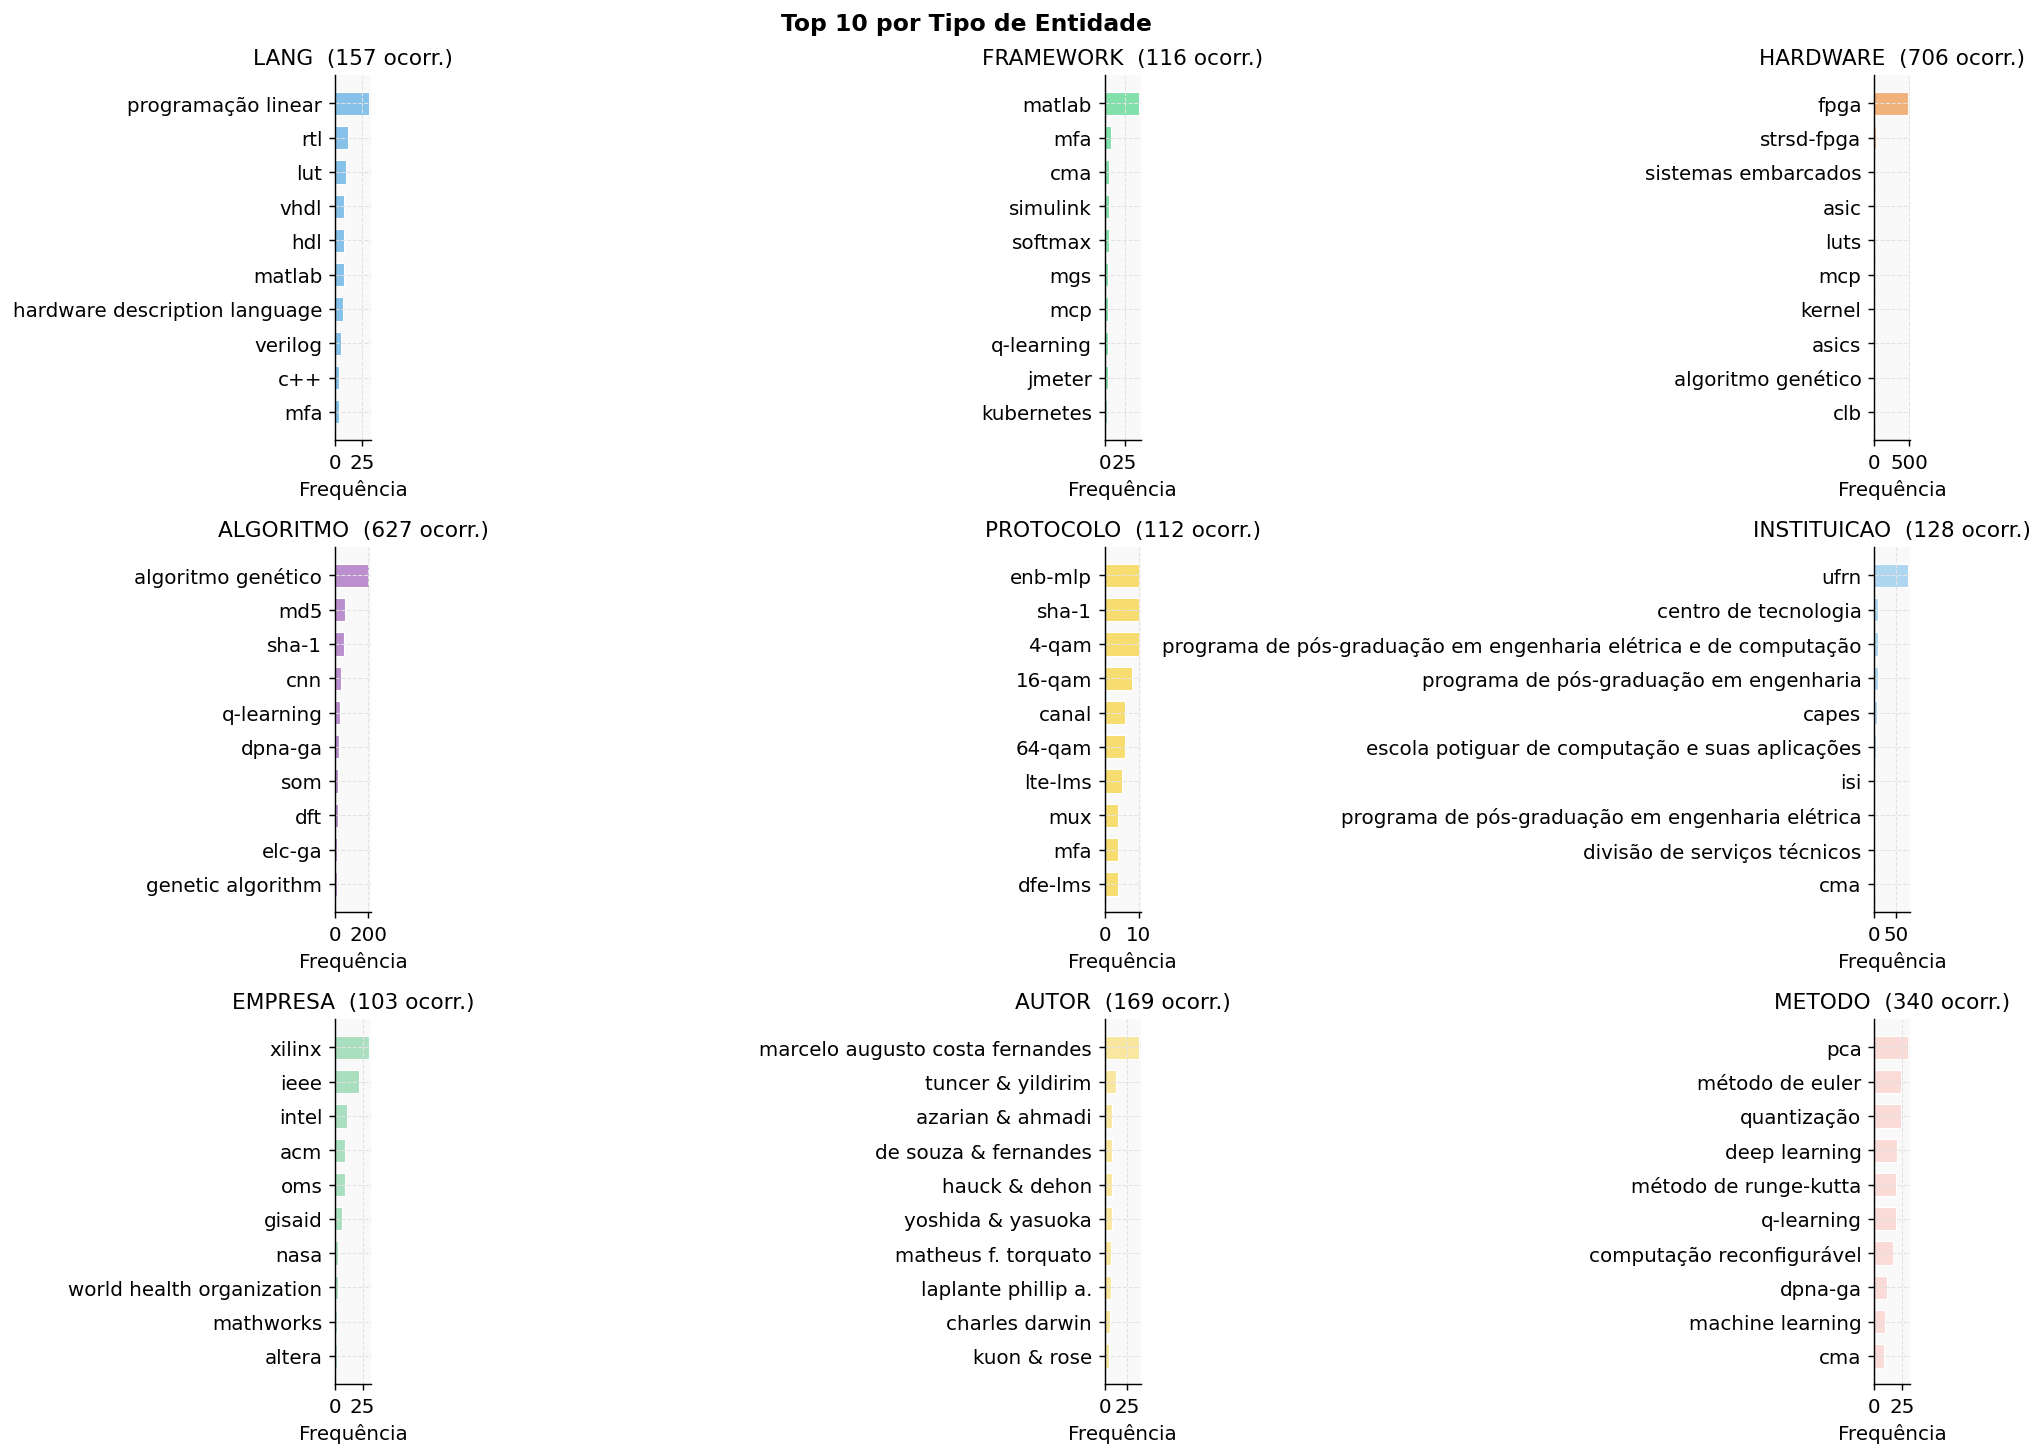

Figura salva: ../figures/02_ner_analysis/08_top10_por_tipo.png


In [19]:
# ── Top-10 por tipo ───────────────────────────────────────────────────────────
tipos_presentes = [l for l in SHORT_LABELS if l in df["label"].values]
n_tipos = len(tipos_presentes)
n_cols  = 3
n_rows  = (n_tipos + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.8))
fig.suptitle("Top 10 por Tipo de Entidade", fontsize=13, fontweight="bold")
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

for ax, lbl in zip(axes_flat, tipos_presentes):
    subset = df[df["label"] == lbl]
    top    = subset["text_norm"].value_counts().head(10).sort_values()
    cor    = LABEL_COLORS.get(lbl, "#aaaaaa")
    ax.barh(top.index, top.values, color=cor, edgecolor="white",
            linewidth=0.6, height=0.68)
    ax.set_title(f"{lbl}  ({len(subset):,} ocorr.)")
    ax.set_xlabel("Frequência")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in list(axes_flat)[len(tipos_presentes):]:
    ax.set_visible(False)

plt.tight_layout()
fig_path = DIR_FIGURES / "08_top10_por_tipo.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">9. Visualização Anotada</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  Renderizador HTML que destaca entidades diretamente no texto, por tipo e cor.
  Seleciona automaticamente os chunks mais ricos em entidades para exibição.
</p>

In [20]:
LABEL_BG = {l: c + "88" for l, c in LABEL_COLORS.items()}  # cor com transparência
LABEL_BD = {"LANG": "#1a6fa0", "FRAMEWORK": "#1a7a4a", "HARDWARE": "#b05c10",
             "ALGORITMO": "#6b3fa0", "PROTOCOLO": "#a08a00", "INSTITUICAO": "#2060a0",
             "EMPRESA": "#206040", "AUTOR": "#a07000", "METODO": "#a03030"}


def render_ner(text: str, entities: list[dict], title: str = "") -> None:
    """Renderiza texto com entidades destacadas por tipo (estilo displacy)."""
    result = text
    sorted_ents = sorted({e["text"] for e in entities}, key=len, reverse=True)
    for ent_text in sorted_ents:
        lbl = next((e["label"] for e in entities if e["text"] == ent_text), "METODO")
        bg  = LABEL_COLORS.get(lbl, "#f0f0f0")
        bd  = LABEL_BD.get(lbl, "#555")
        span = (
            f'<mark style="background:{bg};border:1px solid {bd};border-radius:3px;'
            f'padding:1px 5px;margin:0 1px;font-family:monospace;font-size:0.88em;">'
            f'{ent_text} <sup style="color:{bd};font-size:0.7em;font-family:sans-serif;">{lbl}</sup></mark>'
        )
        result = re.sub(re.escape(ent_text), span, result, count=1, flags=re.IGNORECASE)

    legend = " ".join(
        f'<span style="background:{LABEL_COLORS[l]};border:1px solid {LABEL_BD.get(l,"#555")};'
        f'border-radius:2px;padding:1px 6px;font-size:0.78em;font-family:sans-serif;">{l}</span>'
        for l in tipos_presentes
    )
    html = f"""
    <div style="font-family:sans-serif;font-size:0.82em;color:#888;margin-bottom:6px;">{legend}</div>
    <div style="font-family:Georgia,serif;font-size:0.95em;line-height:1.9;background:#fdfdfd;
                border:1px solid #e8e8e8;border-radius:4px;padding:12px 16px;max-width:860px;color:#222;">
        {f'<strong style="font-family:sans-serif;font-size:0.78em;color:#888;display:block;margin-bottom:6px;">{title}</strong>' if title else ''}
        {result}
    </div>"""
    display(HTML(html))


print("Função render_ner definida.")

Função render_ner definida.


In [21]:
def find_rich_chunk(tese_id: str, min_ents: int = 3) -> tuple:
    """Retorna (chunk_texto, entidades) do chunk mais rico em entidades."""
    df_t    = df[df["tese_id"] == tese_id]
    counts  = df_t.groupby("chunk_idx").size()
    counts  = counts[counts >= min_ents]
    if counts.empty:
        return None, []
    best    = counts.idxmax()
    chunks  = CHUNKS.get(tese_id, [])
    text    = chunks[best] if best < len(chunks) else ""
    ents    = df_t[df_t["chunk_idx"] == best].to_dict("records")
    return text, ents


# Exibe exemplos de dois temas distintos
shown = 0
for tid in TESE_IDS:
    text, ents = find_rich_chunk(tid, min_ents=3)
    if text and len(ents) >= 3:
        row = meta[meta["tese_id"] == tid]
        lbl = row["label_eixo"].values[0] if len(row) else tid
        render_ner(text, ents, title=f"{tid} — {lbl}")
        shown += 1
        if shown >= 3:
            break

In [22]:
# ── Salva exemplo anotado como HTML ──────────────────────────────────────────
for tid in TESE_IDS:
    text, ents = find_rich_chunk(tid, min_ents=4)
    if not text:
        continue

    result = text
    for ent_text in sorted({e["text"] for e in ents}, key=len, reverse=True):
        lbl  = next((e["label"] for e in ents if e["text"] == ent_text), "METODO")
        bg   = LABEL_COLORS.get(lbl, "#f0f0f0")
        bd   = LABEL_BD.get(lbl, "#555")
        span = (f'<mark style="background:{bg};border:1px solid {bd};border-radius:3px;'
                f'padding:1px 5px;">{ent_text} <sup style="color:{bd};font-size:0.7em">{lbl}</sup></mark>')
        result = re.sub(re.escape(ent_text), span, result, count=1, flags=re.IGNORECASE)

    html_page = (
        "<!DOCTYPE html><html><head><meta charset='utf-8'>"
        "<title>NER GLiNER</title></head>"
        f"<body style='font-family:Georgia,serif;max-width:860px;margin:40px auto;'>"
        f"<h3 style='font-family:sans-serif;color:#888'>Exemplo NER — {tid}</h3>"
        f"<p style='line-height:1.9;font-size:1.05em'>{result}</p></body></html>"
    )
    out_html = DIR_FIGURES / "09_ner_exemplo_anotado.html"
    out_html.write_text(html_page, encoding="utf-8")
    print(f"HTML salvo: {out_html}")
    break

HTML salvo: ../figures/02_ner_analysis/09_ner_exemplo_anotado.html


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">10. Avaliação de Qualidade — Prévia do Grafo</h2>
<p style="font-family:sans-serif;font-size:0.9em;color:#555;line-height:1.65;max-width:820px;">
  A métrica de qualidade mais honesta para este projeto não é o número de entidades extraídas,
  mas a interpretabilidade dos pares que vão formar as arestas do grafo.
  Esta seção computa as co-ocorrências por chunk (janela de contexto imediato) e lista
  os 30 pares mais frequentes. Se os pares fazem sentido semanticamente, o pipeline está correto.
</p>

In [23]:
# ── Top-30 pares de co-ocorrência (por chunk) ─────────────────────────────────
cooc = Counter()

for (tid, cidx), group in df.groupby(["tese_id", "chunk_idx"]):
    ents_no_chunk = list(group["text_norm"].unique())
    for a, b in combinations(sorted(ents_no_chunk), 2):
        cooc[(a, b)] += 1

print(f"Pares únicos de co-ocorrência: {len(cooc):,}\n")
print(f"  {'Freq':>5}  {'Entidade A':30}  {'Entidade B'}")
print("  " + "-" * 72)
for (a, b), cnt in cooc.most_common(30):
    lbl_a = df[df["text_norm"] == a]["label"].mode()
    lbl_b = df[df["text_norm"] == b]["label"].mode()
    ta = lbl_a.iloc[0] if len(lbl_a) else "?"
    tb = lbl_b.iloc[0] if len(lbl_b) else "?"
    print(f"  {cnt:>5}  [{ta:11s}] {a:28s}  [{tb:11s}] {b}")

Pares únicos de co-ocorrência: 359

   Freq  Entidade A                      Entidade B
  ------------------------------------------------------------------------
     44  [ALGORITMO  ] algoritmo genético            [HARDWARE   ] fpga
     33  [ALGORITMO  ] md5                           [ALGORITMO  ] sha-1
     16  [HARDWARE   ] fpga                          [AUTOR      ] marcelo augusto costa fernandes
     14  [HARDWARE   ] fpga                          [ALGORITMO  ] md5
     13  [HARDWARE   ] fpga                          [ALGORITMO  ] sha-1
     12  [HARDWARE   ] asic                          [HARDWARE   ] fpga
     12  [HARDWARE   ] fpga                          [ALGORITMO  ] q-learning
     10  [INSTITUICAO] centro de tecnologia          [INSTITUICAO] ufrn
     10  [HARDWARE   ] fpga                          [INSTITUICAO] ufrn
     10  [HARDWARE   ] fpga                          [EMPRESA    ] xilinx
      9  [INSTITUICAO] programa de pós-graduação em engenharia elétrica e de comp

In [24]:
# ── Candidatos a hubs (entidades de maior grau potencial) ─────────────────────
# Conta em quantos pares cada entidade aparece
hub_score = Counter()
for (a, b), cnt in cooc.items():
    hub_score[a] += cnt
    hub_score[b] += cnt

print("Top 20 candidatos a hub no grafo (por força total de co-ocorrência):\n")
print(f"  {'Força':>7}  {'Tipo':12}  Entidade")
print("  " + "-" * 55)
for ent, score in hub_score.most_common(20):
    lbl = df[df["text_norm"] == ent]["label"].mode()
    t   = lbl.iloc[0] if len(lbl) else "?"
    print(f"  {score:>7}  [{t:11s}]  {ent}")

Top 20 candidatos a hub no grafo (por força total de co-ocorrência):

    Força  Tipo          Entidade
  -------------------------------------------------------
      314  [HARDWARE   ]  fpga
      109  [ALGORITMO  ]  algoritmo genético
       64  [INSTITUICAO]  ufrn
       64  [AUTOR      ]  marcelo augusto costa fernandes
       63  [ALGORITMO  ]  md5
       62  [ALGORITMO  ]  sha-1
       33  [EMPRESA    ]  xilinx
       31  [FRAMEWORK  ]  matlab
       28  [INSTITUICAO]  centro de tecnologia
       25  [ALGORITMO  ]  q-learning
       21  [INSTITUICAO]  programa de pós-graduação em engenharia elétrica e de computação
       21  [LANG       ]  vhdl
       21  [AUTOR      ]  matheus f. torquato
       21  [HARDWARE   ]  asic
       19  [METODO     ]  método de euler
       18  [METODO     ]  deep learning
       17  [LANG       ]  rtl
       17  [ALGORITMO  ]  cma
       16  [METODO     ]  método de runge-kutta
       16  [FRAMEWORK  ]  mlp-ad


Score de confiança GLiNER por tipo:

             score_médio  score_mín  ocorrências
label                                           
AUTOR              0.873      0.756          169
INSTITUICAO        0.822      0.454          128
EMPRESA            0.677      0.388          103
LANG               0.677      0.402          157
HARDWARE           0.670      0.380          706
ALGORITMO          0.657      0.401          627
METODO             0.643      0.450          340
PROTOCOLO          0.635      0.383          112
FRAMEWORK          0.623      0.381          116


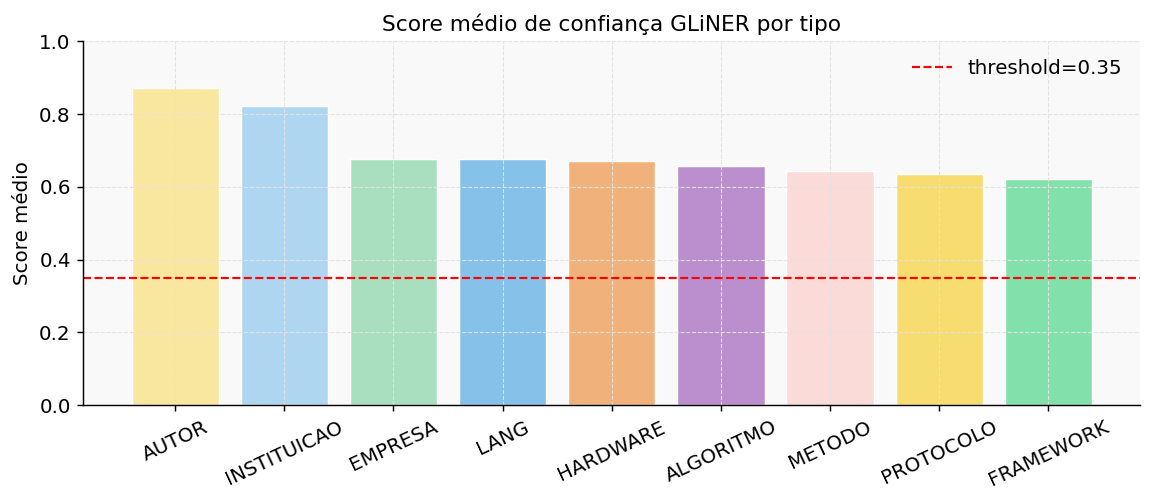

Figura salva: ../figures/02_ner_analysis/10_gliner_score_por_tipo.png


In [25]:
# ── Score médio de confiança por tipo ────────────────────────────────────────
score_by_type = df.groupby("label")["score"].agg(["mean", "min", "count"])
score_by_type.columns = ["score_médio", "score_mín", "ocorrências"]
score_by_type = score_by_type.sort_values("score_médio", ascending=False)

print("Score de confiança GLiNER por tipo:\n")
print(score_by_type.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
tipos_score = score_by_type.index.tolist()
cores_score = [LABEL_COLORS.get(l, "#aaaaaa") for l in tipos_score]
ax.bar(tipos_score, score_by_type["score_médio"].values,
       color=cores_score, edgecolor="white", linewidth=0.8)
ax.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.2,
           label=f"threshold={THRESHOLD}")
ax.set_ylim(0, 1)
ax.set_title("Score médio de confiança GLiNER por tipo")
ax.set_ylabel("Score médio")
ax.tick_params(axis="x", rotation=25)
ax.legend(frameon=False)
plt.tight_layout()
fig_path = DIR_FIGURES / "10_gliner_score_por_tipo.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">11. Distribuição por Documento</h2>

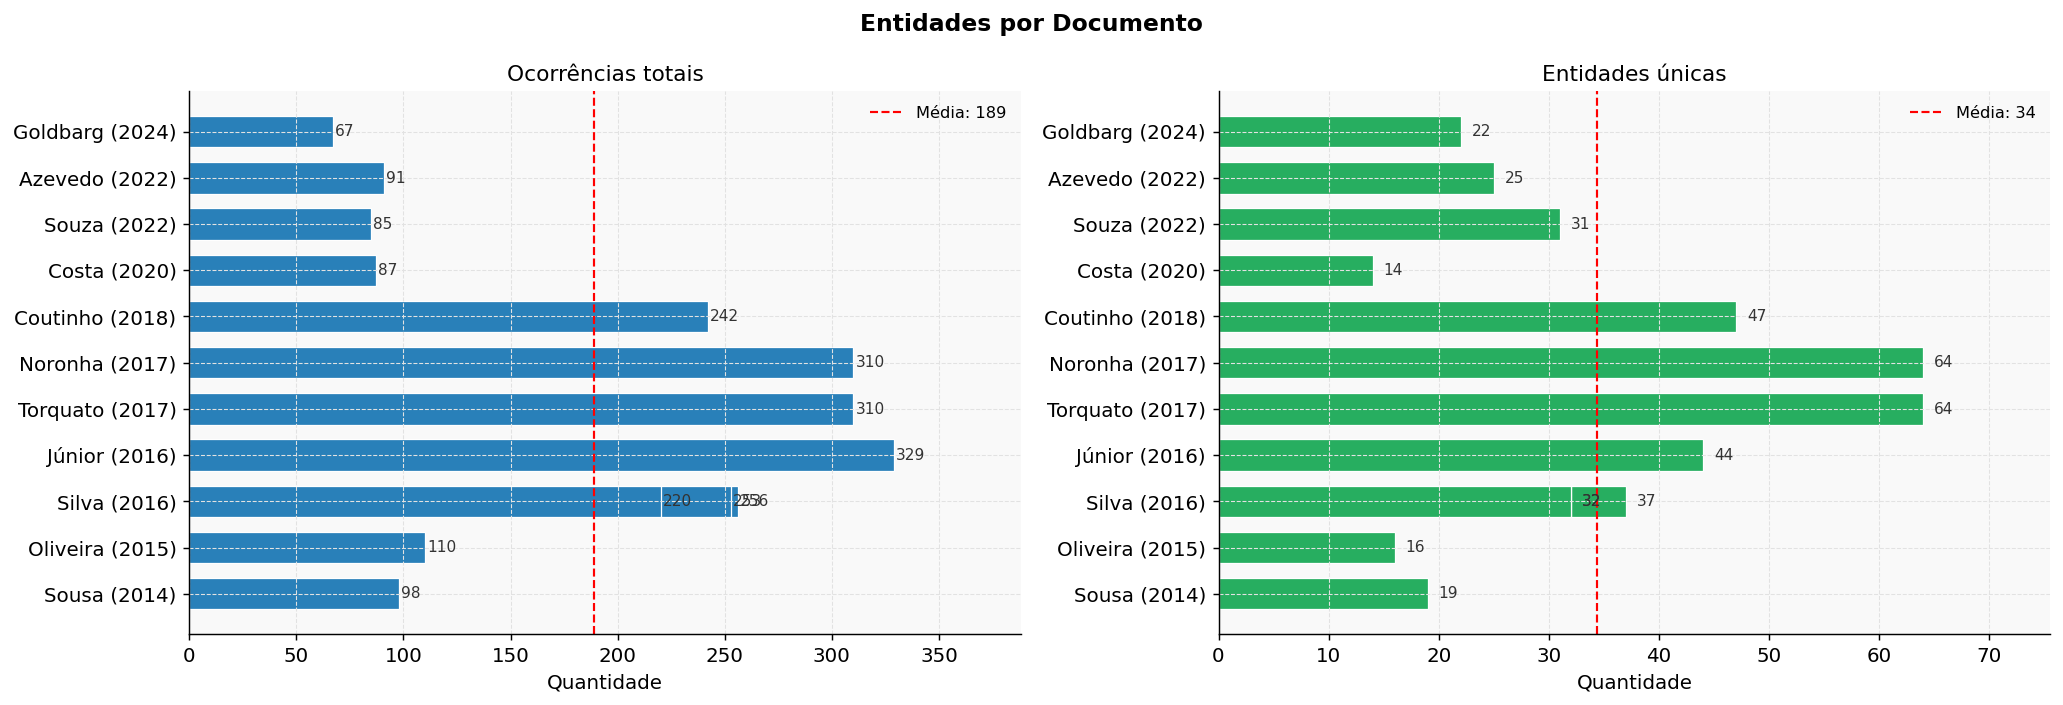

Figura salva: ../figures/02_ner_analysis/11_entidades_por_documento.png


In [26]:
# ── Entidades por documento (ordenado cronologicamente) ──────────────────────
if "ano" in meta.columns:
    ordem = meta.sort_values("ano")["tese_id"].tolist()
else:
    ordem = sorted(TESE_IDS)

labels_eixo = [
    meta[meta["tese_id"] == tid]["label_eixo"].values[0]
    if len(meta[meta["tese_id"] == tid]) > 0 else tid
    for tid in ordem
]

counts = df.groupby("tese_id").size().reindex(ordem, fill_value=0)
uniques = df.groupby("tese_id")["text_norm"].nunique().reindex(ordem, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle("Entidades por Documento", fontsize=13, fontweight="bold")

for ax, values, title, cor in [
    (axes[0], counts,  "Ocorrências totais",   "#2980b9"),
    (axes[1], uniques, "Entidades únicas",      "#27ae60"),
]:
    media = values.mean()
    bars  = ax.barh(labels_eixo, values.values,
                    color=cor, edgecolor="white", linewidth=0.7, height=0.68)
    ax.axvline(media, color="red", linestyle="--", linewidth=1.2,
               label=f"Média: {media:.0f}")
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 1, bar.get_y() + bar.get_height()/2,
                f"{w:,.0f}", va="center", fontsize=8.5, color="#333")
    ax.set_title(title)
    ax.set_xlabel("Quantidade")
    ax.set_xlim(0, values.max() * 1.18)
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
fig_path = DIR_FIGURES / "11_entidades_por_documento.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

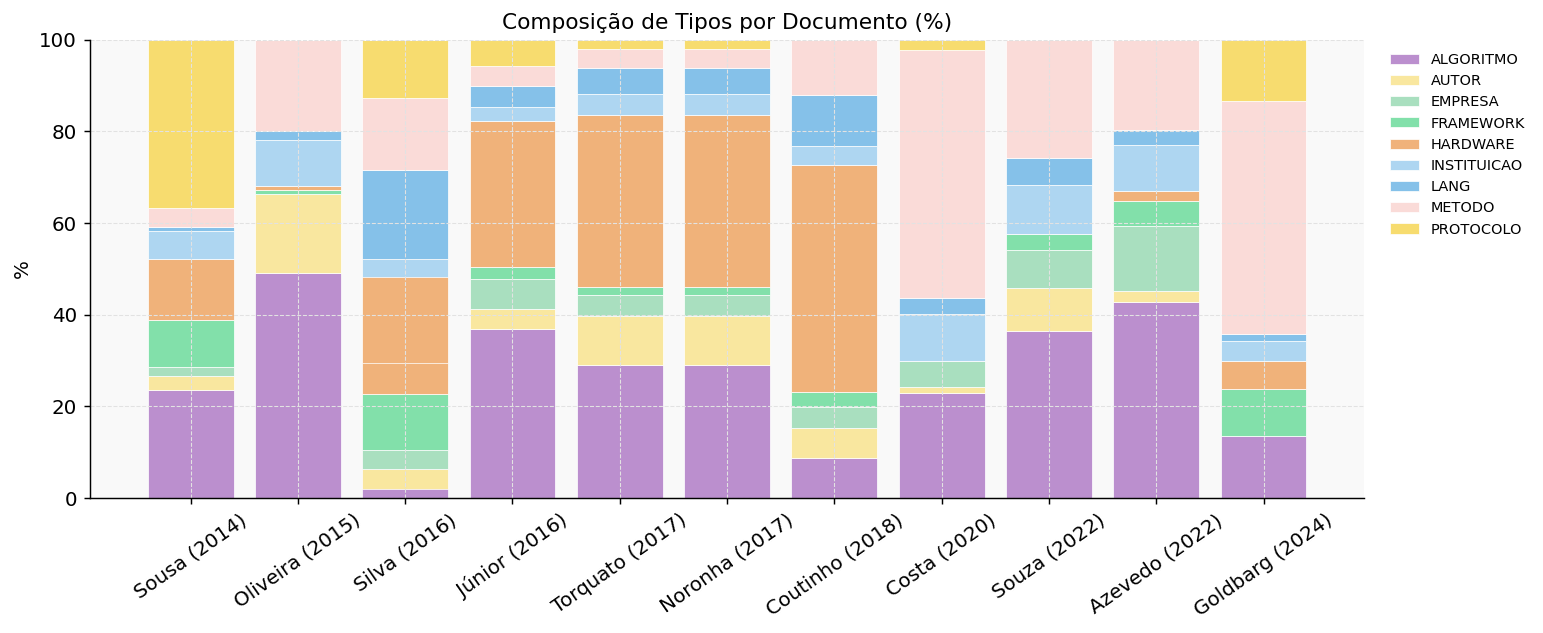

Figura salva: ../figures/02_ner_analysis/12_composicao_tipos_por_doc.png


In [27]:
# ── Composição por tipo × documento (heatmap de proporção) ───────────────────
pivot = (
    df.groupby(["tese_id", "label"]).size()
    .unstack(fill_value=0)
    .reindex(ordem)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(pivot_pct))
for lbl in pivot_pct.columns:
    cor = LABEL_COLORS.get(lbl, "#aaaaaa")
    ax.bar(labels_eixo, pivot_pct[lbl].values, bottom=bottom,
           color=cor, edgecolor="white", linewidth=0.4, label=lbl)
    bottom += pivot_pct[lbl].values

ax.set_title("Composição de Tipos por Documento (%)")
ax.set_ylabel("%")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=35)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)

plt.tight_layout()
fig_path = DIR_FIGURES / "12_composicao_tipos_por_doc.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">12. Síntese e Exportação</h2>

In [28]:
# ── Exporta DataFrame filtrado completo ──────────────────────────────────────
out_csv = DIR_RESULTS / "02_all_entities_gliner.csv"
df.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"Entidades exportadas: {out_csv}")

# ── Exporta resumo por documento × tipo ──────────────────────────────────────
summary_rows = []
for tid in TESE_IDS:
    sub  = df[df["tese_id"] == tid]
    row  = {"tese_id": tid, "total": len(sub), "unicas": sub["text_norm"].nunique()}
    for lbl in SHORT_LABELS:
        row[lbl.lower()] = (sub["label"] == lbl).sum()
    summary_rows.append(row)
df_summary = pd.DataFrame(summary_rows)
out_sum = DIR_RESULTS / "02_ner_summary_gliner.csv"
df_summary.to_csv(out_sum, index=False, encoding="utf-8-sig")
print(f"Resumo exportado: {out_sum}")

Entidades exportadas: ../results/02_ner_analysis/02_all_entities_gliner.csv
Resumo exportado: ../results/02_ner_analysis/02_ner_summary_gliner.csv


In [29]:
sep = "=" * 58
print(sep)
print("  RESUMO DO NER — GLiNER")
print(sep)
print(f"  Modelo              : {GLINER_MODEL_ID}")
print(f"  Threshold           : {THRESHOLD}")
print(f"  Frequência mínima   : {FREQ_MIN}")
print(f"  Documentos          : {len(TESE_IDS)}")
print(f"  Chunks processados  : {total_chunks:,}")
print()
print(f"  Ocorrências totais  : {len(df_raw):>7,}  (bruto)")
print(f"  Após filtros        : {len(df):>7,}")
print(f"  Entidades únicas    : {df['text_norm'].nunique():>7,}")
print()
for lbl in SHORT_LABELS:
    cnt = (df["label"] == lbl).sum()
    if cnt > 0:
        uniq = df[df["label"]==lbl]["text_norm"].nunique()
        print(f"  {lbl:13s}  : {cnt:>6,} ocorr.  |  {uniq:>4} únicas")
print()
print(f"  Pares de co-ocorrência : {len(cooc):,}")
print(f"  JSONs em data/entities/gliner/ : {len(list(DIR_ENT.glob('*.json')))}")
print(f"  Figuras em figures/02_ner_analysis/ : {len(list(DIR_FIGURES.glob('*.png')))} PNGs")
print(sep)

  RESUMO DO NER — GLiNER
  Modelo              : urchade/gliner_multi-v2.1
  Threshold           : 0.35
  Frequência mínima   : 3
  Documentos          : 13
  Chunks processados  : 3,567

  Ocorrências totais  :   6,512  (bruto)
  Após filtros        :   2,458
  Entidades únicas    :     197

  LANG           :    157 ocorr.  |    37 únicas
  FRAMEWORK      :    116 ocorr.  |    25 únicas
  HARDWARE       :    706 ocorr.  |    49 únicas
  ALGORITMO      :    627 ocorr.  |    50 únicas
  PROTOCOLO      :    112 ocorr.  |    32 únicas
  INSTITUICAO    :    128 ocorr.  |    11 únicas
  EMPRESA        :    103 ocorr.  |    14 únicas
  AUTOR          :    169 ocorr.  |    27 únicas
  METODO         :    340 ocorr.  |    57 únicas

  Pares de co-ocorrência : 359
  JSONs em data/entities/gliner/ : 13
  Figuras em figures/02_ner_analysis/ : 6 PNGs


<h2 style="font-family:Georgia,serif;color:#2c3e50;border-bottom:1px solid #dce0e4;padding-bottom:6px;margin-top:30px;">13. Observações e Próximos Passos</h2>

<h3 style="font-family:sans-serif;font-weight:600;color:#34495e;font-size:0.95em;margin-bottom:4px;">Calibração do threshold</h3>
<p style="font-family:sans-serif;font-size:0.88em;color:#777;font-style:italic;max-width:820px;line-height:1.7;">
  [ Preencher: o threshold escolhido produziu entidades coerentes? Os pares do top-30 fazem sentido?
  Há tipos com score médio abaixo de 0.40, indicando baixa confiança? ]
</p>

<h3 style="font-family:sans-serif;font-weight:600;color:#34495e;font-size:0.95em;margin-bottom:4px;">Qualidade por tipo</h3>
<p style="font-family:sans-serif;font-size:0.88em;color:#777;font-style:italic;max-width:820px;line-height:1.7;">
  [ Preencher: quais tipos tiveram melhor qualidade? HARDWARE e ALGORITMO costumam ser mais
  precisos em texto técnico. AUTOR e PROTOCOLO tendem a ter mais falsos positivos em textos curtos. ]
</p>

<h3 style="font-family:sans-serif;font-weight:600;color:#34495e;font-size:0.95em;margin-bottom:4px;">Ajustes ao NORM_MAP</h3>
<p style="font-family:sans-serif;font-size:0.88em;color:#777;font-style:italic;max-width:820px;line-height:1.7;">
  [ Preencher: quais variantes de entidade (plurais, grafias) ficaram faltando no NORM_MAP
  e precisam ser adicionadas antes de construir o grafo? ]
</p>

<h3 style="font-family:sans-serif;font-weight:600;color:#34495e;font-size:0.95em;margin-bottom:4px;">Próximos passos</h3>
<ul style="font-family:sans-serif;font-size:0.88em;color:#555;line-height:1.85;max-width:780px;">
  <li>Ajustar <code>THRESHOLD</code> e <code>FREQ_MIN</code> se necessário e reprocessar
      (deletar JSONs do cache para forçar nova extração).</li>
  <li>Completar o <code>NORM_MAP</code> com variantes identificadas na inspeção das top-25.</li>
  <li>Executar o <strong>Notebook 03</strong> — constrói os grafos de coocorrência por sentença,
      parágrafo e janela de k-chars a partir de <code>data/entities/gliner/</code>.</li>
</ul>